<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/30_Experimental_Design_in_Python/03_Analyzing_Experimental_Data_Statistical_Tests_and_Power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from statsmodels.stats.power import TTestIndPower

In [20]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/chemical_reactions.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
chemical_reactions = pd.read_csv(url)
display(chemical_reactions.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/hr_wellness.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
hr_wellness = pd.read_csv(url)
display(hr_wellness.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/investment_returns.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
investment_returns = pd.read_csv(url)
display(investment_returns.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/toy_durability.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
toy_durability = pd.read_csv(url)
display(toy_durability.head())

,Catalyst,Reaction_Time
0,Palladium,47.483571
1,Palladium,44.308678
2,Palladium,48.238443
3,Palladium,52.615149
4,Palladium,43.829233


,Department,Wellness_Program_Status
0,Marketing,Enrolled
1,Sales,Enrolled
2,Marketing,Not Enrolled
3,Marketing,Not Enrolled
4,Sales,Enrolled


,Strategy_Type,Annual_Return
0,Quantitative,10.597379
1,Quantitative,1.656248
2,Quantitative,9.202100
3,Quantitative,3.980213
4,Quantitative,8.086720


,Toy_Type,Durability_Score
0,Recreational,67.2
1,Recreational,80.9
2,Recreational,69.7
3,Recreational,82.7
4,Educational,79.6


**Choosing the right test: petrochemicals**  
In a chemistry research lab, scientists are examining the efficiency of three well-known catalysts—Palladium (Pd), Platinum (Pt), and Nickel (Ni)—in facilitating a particular reaction. Each catalyst is used in a set of identical reactions under controlled conditions, and the time taken for each reaction to reach completion is meticulously recorded. Your goal is to compare the mean reaction times across the three catalyst groups to identify which catalyst, if any, has a significantly different reaction time.

The data is available in the chemical_reactions DataFrame. pandas as pd, numpy as np, and the following functions have been loaded as well:

    from scipy.stats import ttest_ind
    from scipy.stats import f_oneway
    from scipy.stats import chi2_contingency

In [9]:
catalyst_types = ['Palladium', 'Platinum', 'Nickel']

# Collect reaction times for each catalyst into a list
groups = [chemical_reactions[chemical_reactions['Catalyst'] == catalyst]['Reaction_Time'] for catalyst in catalyst_types]

# Perform the one-way ANOVA across the three groups
f_stat, p_val = f_oneway(*groups)
print(p_val)

# Assume a significance level of 0.01. What is the appropriate conclusion to glean from the P-value in comparison with this
# a value?
# -> The P-value is substantially smaller than the
#  value, indicating a significant difference in reaction times across the catalysts.

#  The extremely small P-value strongly suggests significant differences among the catalysts.

4.710677600047866e-151


Choosing the right test: human resources
In human resources, it's essential to understand the relationships between different variables that might influence employee satisfaction or turnover. Consider a scenario where an HR department is interested in understanding the association between the department in which employees work and their participation in a new workplace wellness program. The HR team has compiled this data over the past two years and has asked you if there's any significant association between an employee's department and their enrolling in the wellness program.

The data is available in the hr_wellness DataFrame. pandas as pd, numpy as np, and the following functions have been loaded:

    from scipy.stats import ttest_ind
    from scipy.stats import f_oneway
    from scipy.stats import chi2_contingency

In [12]:
# Create a contingency table
contingency_table = pd.crosstab(
  hr_wellness['Department'],
  hr_wellness['Wellness_Program_Status']
)

# Perform the chi-square test of association
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
print(p_val)

# ? Assume a significance level of 0.05. Given the P-value, what is the appropriate conclusion?
# -> There's no significant association between department and enrollment in the wellness program, as the P-value is larger than 0.05.

# The P-value being greater than 0.05 suggests no significant association between the variables.

0.17573344450112738


**Choosing the right test: finance**  
In the realm of finance, investment strategists are continually evaluating different approaches to maximize returns. Consider a scenario where a financial firm wishes to assess the effectiveness of two investment strategies: "Quantitative Analysis" and "Fundamental Analysis". The firm has applied each strategy to a separate set of investment portfolios for a year and now asks you to compare the annual returns to determine if there is any difference in strategy returns by comparing the mean returns of the two groups.

The data is available in the investment_returns DataFrame. pandas as pd, numpy as np, and the following functions have been loaded as well:

    from scipy.stats import ttest_ind
    from scipy.stats import f_oneway
    from scipy.stats import chi2_contingency

In [15]:
# Separate the annual returns by strategy type
quantitative_returns = investment_returns[investment_returns['Strategy_Type'] == 'Quantitative']['Annual_Return']
fundamental_returns = investment_returns[investment_returns['Strategy_Type'] == 'Fundamental']['Annual_Return']

# Perform the independent samples t-test between the two groups
t_stat, p_val = ttest_ind(quantitative_returns, fundamental_returns)
print(p_val)

# ? Assume a significance level of 0.1. What is the appropriate conclusion to glean from the P-value in comparison with this
#  value?
#  -> The P-value is much smaller than a, suggesting a significant difference in returns between the two strategies.

#  Given the very small p-value of around 0.000000000000002, we have evidence of a difference in returns for any reasonable choice of alpha.

2.0567003424807146e-14


**Anxiety treatments ANOVA**
Psychologists conducted a study to compare the effectiveness of three types of therapy on reducing anxiety levels: Cognitive Behavioral Therapy (CBT), Dialectical Behavior Therapy (DBT), and Acceptance and Commitment Therapy (ACT). Participants were randomly assigned to one of the three therapy groups, and their anxiety levels were measured before and after the therapy sessions. The psychologists have asked you to determine if there are any significant differences in the effectiveness of these therapies.

The therapy_outcomes DataFrame containing this experiment data has been loaded along with pandas as pd and from scipy.stats import f_oneway.

In [ ]:
# Pivot to view the mean anxiety reduction for each therapy
pivot_table = therapy_outcomes.pivot_table(
    values='Anxiety_Reduction',
    index='Therapy_Type',
    aggfunc="mean")
print(pivot_table)

# Create groups to prepare the data for ANOVA
therapy_types = ['CBT', 'DBT', 'ACT']
groups = [therapy_outcomes[therapy_outcomes['Therapy_Type'] == therapy]['Anxiety_Reduction'] for therapy in therapy_types]

# Conduct ANOVA
f_stat, p_val = f_oneway(*groups)
print(p_val)

# By analyzing the data with ANOVA, you've taken an important step in comparing the
# effectiveness of different therapies. Assuming an alpha of 0.05, the P-value indicates
# significant differences in therapy effectiveness.



**Applying Tukey's HSD**  
Following the ANOVA analysis which suggested significant differences in the effectiveness of the three types of therapy, the psychologists are keen to delve deeper. They wish for you to explain exactly which therapy types differ from each other in terms of reducing anxiety levels. This is where Tukey's Honest Significant Difference (HSD) test comes into play. It's a post-hoc test used to make pairwise comparisons between group means after an ANOVA has shown a significant difference. Tukey's HSD test helps in identifying specific pairs of groups that have significant differences in their means.

The therapy_outcomes DataFrame containing this experiment data has again been loaded along with pandas as pd and `from statsmodels.stats.multicomp import pairwise_tukeyhsd.`

In [ ]:
# Perform Tukey's HSD test
tukey_results = pairwise_tukeyhsd(
    therapy_outcomes['Anxiety_Reduction'],
    therapy_outcomes['Therapy_Type'],
    alpha=0.05
)

print(tukey_results)

#  The Tukey HSD test provided clear insights into which therapy types significantly
#  differ in reducing anxiety. These findings can guide psychologists in refining treatment
#  approaches. Did you catch that ACT and CBT don't differ significantly from this experiment?

Applying Bonferoni correction
After identifying significant differences between therapy groups with Tukey's HSD, we want to confirm our findings with the Bonferroni correction. The Bonferroni correction is a conservative statistical adjustment used to counteract the problem of multiple comparisons. It reduces the chance of obtaining false-positive results by adjusting the significance level. In the context of your study on the effectiveness of CBT, DBT, and ACT, applying the Bonferroni correction will help ensure that the significant differences you observe between therapy groups are not due to chance.

The therapy_outcomes DataFrame has again been loaded along with pandas as pd,

    from scipy.stats import ttest_ind, and from statsmodels.sandbox.stats.multicomp import multipletests.

In [ ]:
p_values = []

therapy_pairs = [('CBT', 'DBT'), ('CBT', 'ACT'), ('DBT', 'ACT')]

# Conduct t-tests and collect P-values
for pair in therapy_pairs:
    group1 = therapy_outcomes[therapy_outcomes['Therapy_Type'] == pair[0]]['Anxiety_Reduction']
    group2 = therapy_outcomes[therapy_outcomes['Therapy_Type'] == pair[1]]['Anxiety_Reduction']
    t_stat, p_val = ttest_ind(group1, group2)
    p_values.append(p_val)

# Apply Bonferroni correction
print(multipletests(p_values, alpha=0.05, method='bonferroni')[1])

# You've adeptly applied the Bonferroni correction to adjust the P-values for
# multiple comparisons. This step is critical to control for Type I error, ensuring
# the reliability of your findings. Here, you again see that ACT and CBT don't differ
# significantly from this experiment due to the corrected P-value of 1.

### p-values, alpha, and errors

**Analyzing toy durability**  
In product development within the toy industry, it's crucial to understand the durability of toys, particularly when comparing educational toys to recreational ones. Durability can significantly impact customer satisfaction and repeat business. Researchers in a toy manufacturing company have asked you to conduct the analysis of a study comparing the durability of educational toys versus recreational toys. The toy_durability DataFrame contains the results of these tests, with durability scores assigned based on rigorous testing protocols.

The data is available in the toy_durability DataFrame. pandas as pd and from scipy.stats import ttest_ind have been loaded.

In [21]:
# Calculate mean Durability_Score for each Toy_Type
# Calculate mean Durability_Score for each Toy_Type
mean_durability = toy_durability.pivot_table(
  values='Durability_Score', index='Toy_Type', aggfunc="mean")
print(mean_durability)

# Perform t-test
educational_durability = toy_durability[toy_durability['Toy_Type'] == 'Educational']['Durability_Score']
recreational_durability = toy_durability[toy_durability['Toy_Type'] == 'Recreational']['Durability_Score']
t_stat, p_val = ttest_ind(educational_durability, recreational_durability)

print(p_val)

# The P-value suggests that there's a statistically significant difference in durability between
# 'Educational' and 'Recreational' toys, assuming an alpha of 0.05. This insight could be crucial
# for product development and marketing strategies.

              Durability_Score
Toy_Type                      
Educational          80.100737
Recreational         79.460632
nan


/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


**Visualizing durability differences**  
Following the analysis of toy durability, the research team is interested in you visualizing the distribution of durability scores for both Educational and Recreational toys. Such visualizations can offer intuitive insights into the data, potentially highlighting the range and variability of scores within each category. This step is essential for presenting findings to non-technical stakeholders and guiding further product development decisions.

The data is available in the toy_durability DataFrame, and seaborn and matplotlib.pyplot as sns and plt respectively are loaded.

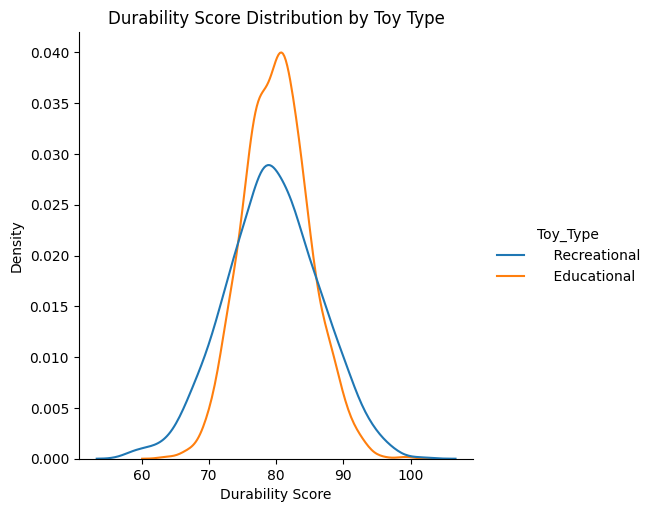

In [22]:


# Visualize the distribution of Durability_Score for each Toy_Type
sns.displot(data=toy_durability, x="Durability_Score",
            hue="Toy_Type", kind="kde")
plt.title('Durability Score Distribution by Toy Type')
plt.xlabel('Durability Score')
plt.ylabel('Density')
plt.show()

# The KDE plot visually illustrates the differences in durability between Educational
# and Recreational toys. You can see that the center of both distributions is near 80
# for the durability score, but Recreational seems more variable than Educational.

**Estimating required sample size for energy study**  
In the energy sector, researchers are often tasked with evaluating the effectiveness of new technologies or initiatives to enhance energy efficiency or reduce consumption. A study is being designed to compare the impact of two energy-saving measures: "Smart Thermostats" and "LED Lighting". To ensure the study has sufficient power to detect a meaningful difference in energy savings between these two measures, you'll conduct a power analysis.

pandas as pd, numpy as np, and from statsmodels.stats.power import TTestIndPower are loaded.

In [26]:
# Instantiate a TTestIndPower object
power_analysis = TTestIndPower()

# Conduct a power analysis to determine the required sample size
required_n = power_analysis.solve_power(
    effect_size=0.5,
    alpha=0.05,
    power=0.9,
    ratio=1)

print(required_n)

# ent! By conducting a power analysis, you've determined that approximately 85
# participants are required in each group to achieve a power of 0.9, assuming an
# Cohen's d effect size of 0.5. This information is crucial for planning a sufficiently
# powered study to compare the energy-saving effectiveness of Smart Thermostats versus LED Lighting.

85.03128411544917
